<a href="https://colab.research.google.com/github/fattah-abdullah/RegresiLinear_kelas5A_kelompok4/blob/main/RegresiLinear_kelas5A_Kelompok4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROSES EDA

In [2]:
# 1. Install library kaggle (biasanya sudah ada di Colab, tapi untuk memastikan)
!pip install -q kaggle

In [3]:
# 2. Mengatur Environment Variable untuk API Token
import os
import getpass

print("Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")

Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


In [4]:
# 3. MENGUNDUH DATASET CONTOH
# Perintah: kaggle datasets download -d [nama-pemilik/nama-dataset]
print("Mengunduh dataset Vehicle From Cardekho...")
!kaggle datasets download -d nehalbirla/vehicle-dataset-from-cardekho

Mengunduh dataset Vehicle From Cardekho...
Dataset URL: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
License(s): DbCL-1.0
100% 292k/292k [00:00<00:00, 97.3MB/s]



In [5]:
# 4. Mengekstrak file ZIP hasil unduhan
# -q artinya 'quiet' (tanpa log ekstraksi yang panjang)
!unzip -q vehicle-dataset-from-cardekho.zip -d vehicle-dataset-from-cardekho/

print("Unduhan dan Ekstraksi Selesai!")

Unduhan dan Ekstraksi Selesai!


In [6]:
# 5. MEMUAT DATA KE PANDAS (Langkah Awal EDA)
import pandas as pd

# Membaca file CSV yang sudah diekstrak
# Sesuaikan nama file CSV dengan isi dari ZIP tersebut
df = pd.read_csv('vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv')

In [7]:
# Menampilkan 5 baris pertama untuk memastikan koneksi dan load data berhasil
print("\n--- 5 Baris Pertama Dataset Vehicle Dataset ---")
display(df.head())


--- 5 Baris Pertama Dataset Vehicle Dataset ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## **Inspeksi Awal Data (Initial Data Inspection)**

In [8]:
# Tampilkan 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir data (opsional, untuk memastikan data dimuat utuh)
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



--- 5 Baris Terakhir Data ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner



Dimensi dataset: 4340 baris, 8 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

--- Daftar Nama Kolom ---
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


## **Pengecekan Kualitas Data Dasar** (Basic Data Quality Checks)

--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)


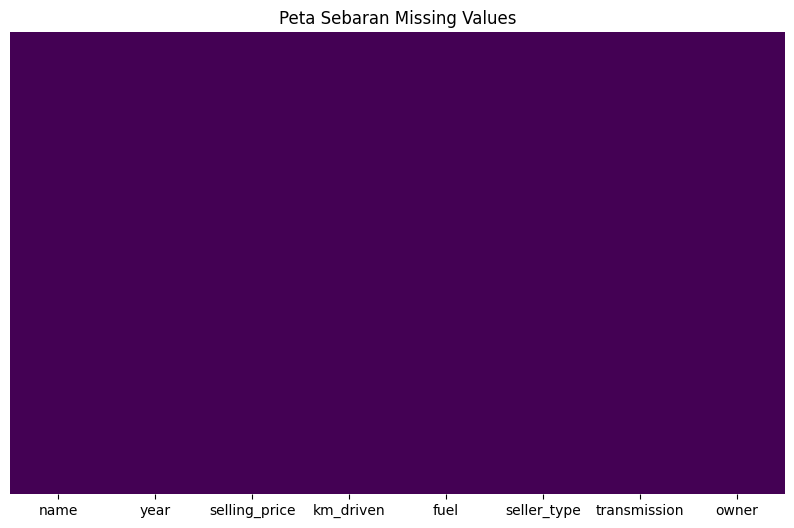


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 763


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3912,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
4016,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
99,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
2578,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
554,Audi A4 3.0 TDI Quattro,2013,1580000,86000,Diesel,Dealer,Automatic,First Owner
...,...,...,...,...,...,...,...,...
2936,Volkswagen Vento 1.5 TDI Highline Plus AT,2017,890000,40219,Diesel,Dealer,Automatic,First Owner
1628,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
3052,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
478,Volkswagen Vento Diesel Highline,2011,300000,65000,Diesel,Individual,Manual,Second Owner


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
# Tampilkan hanya kolom yang memiliki missing value
display(missing_table[missing_table['Jumlah Missing'] > 0])

# Visualisasi Missing Values (Menggunakan Heatmap seaborn)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")

## **Statistik Deskriptif (Descriptive Statistics)**

In [10]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,name,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340,4340
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,69,2153,3244,3892,2832


## **Analisis Univariat (Univariate Analysis)**

### Analisis Univariat untuk Kolom Numerik ###


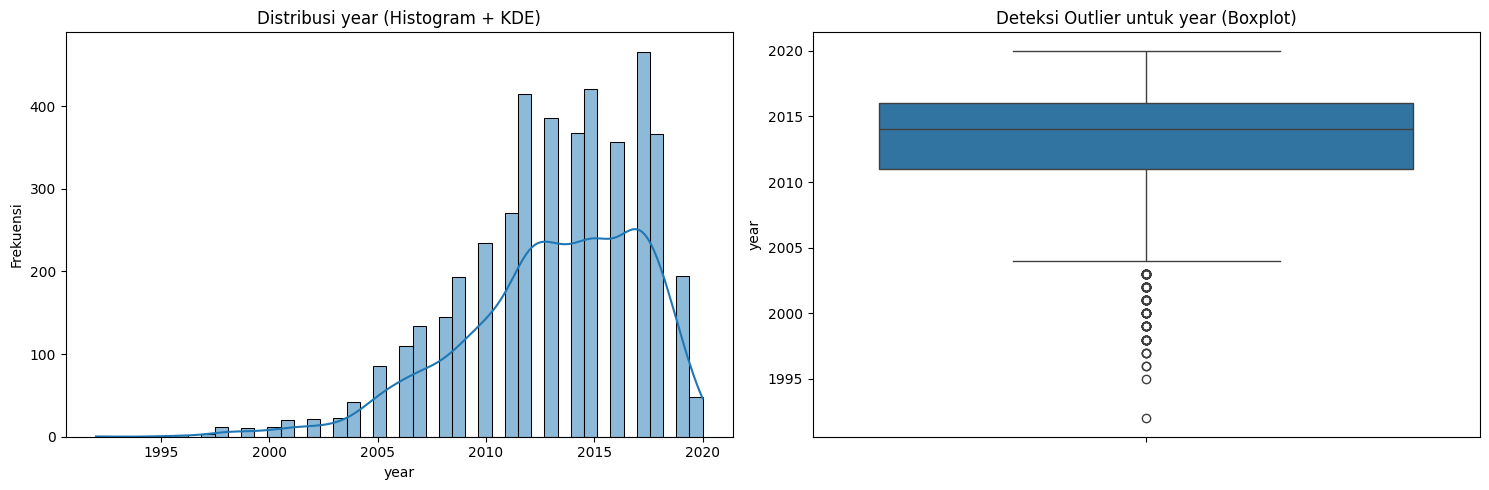

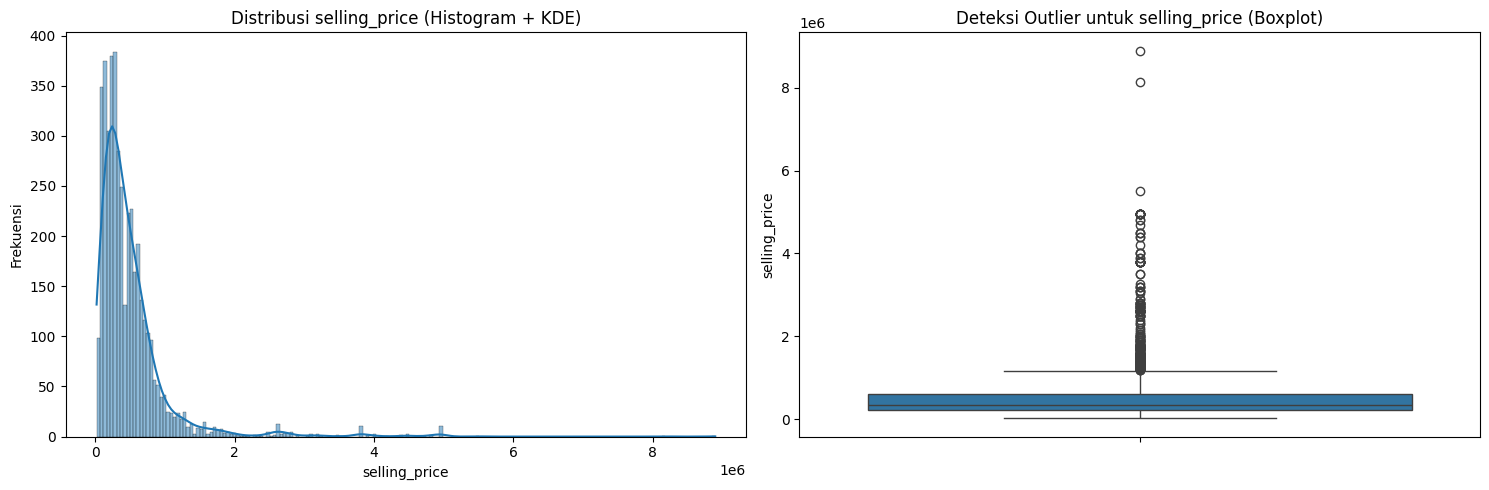

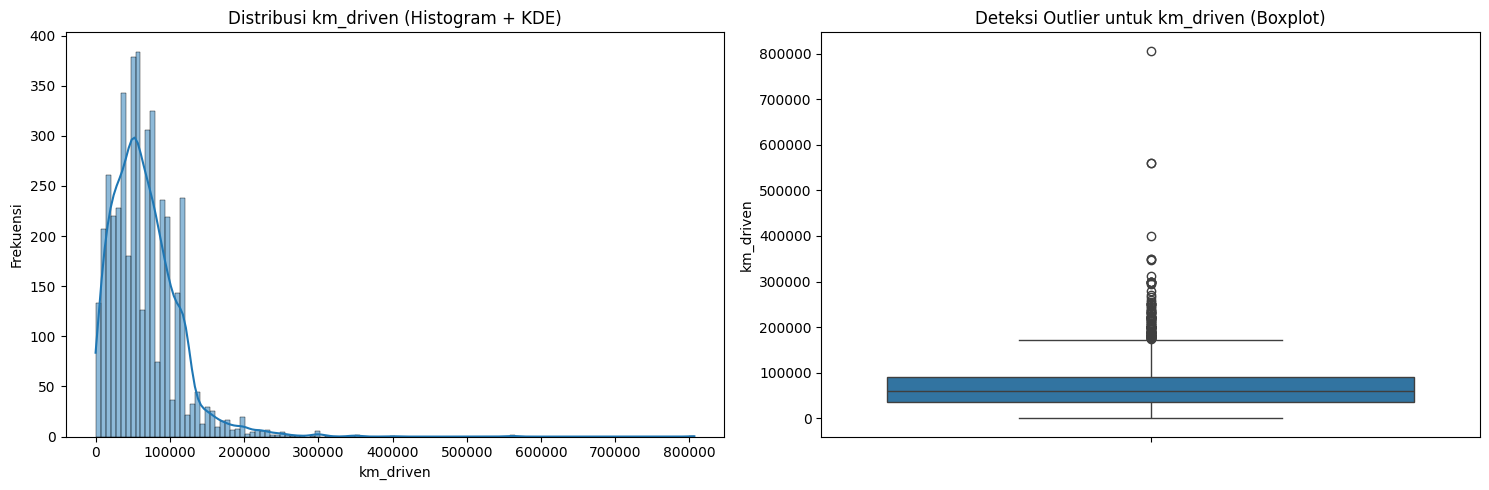


### Analisis Univariat untuk Kolom Kategorikal ###


/tmp/ipykernel_1223/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


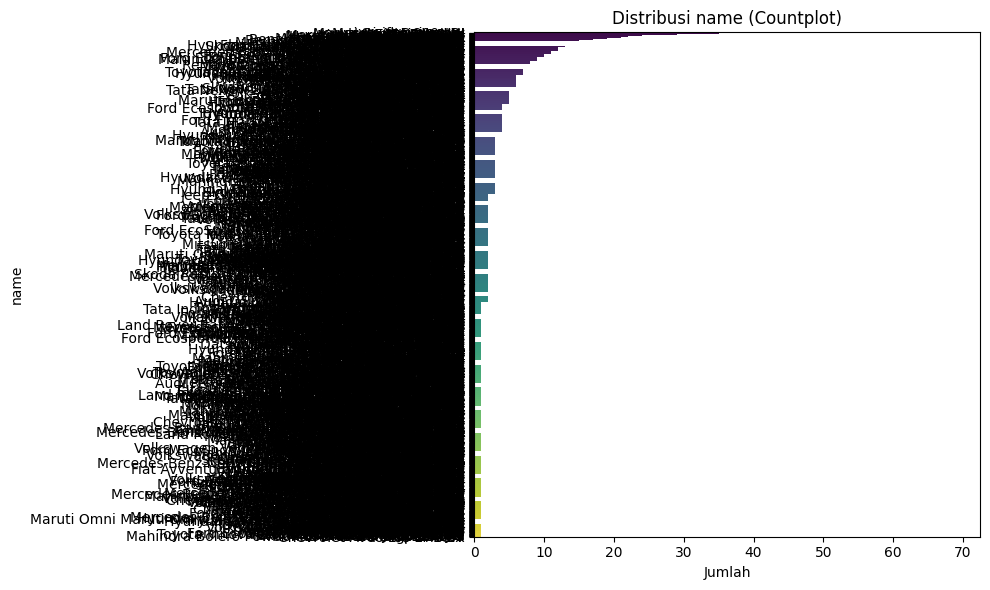

/tmp/ipykernel_1223/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


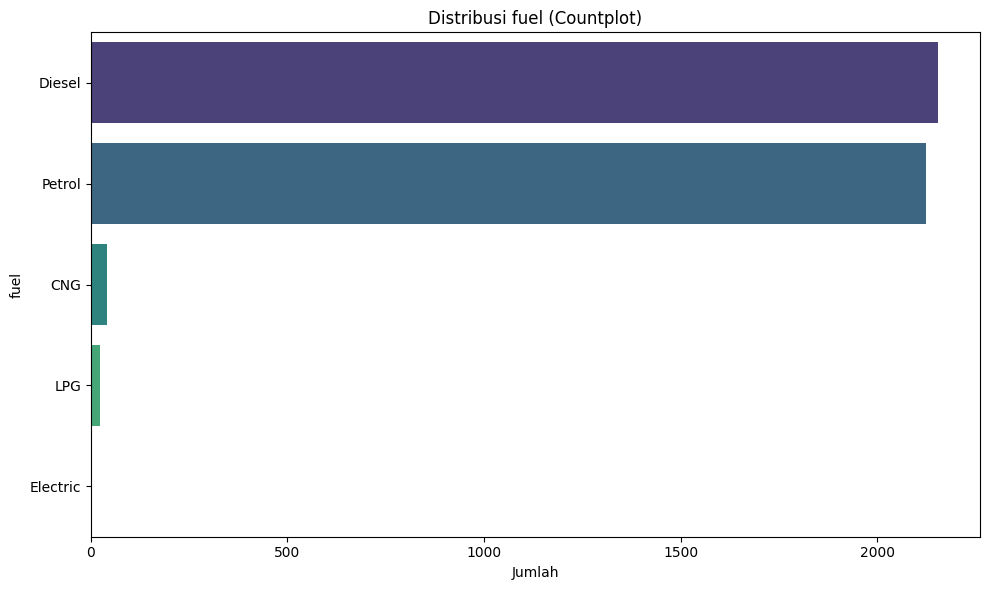

/tmp/ipykernel_1223/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


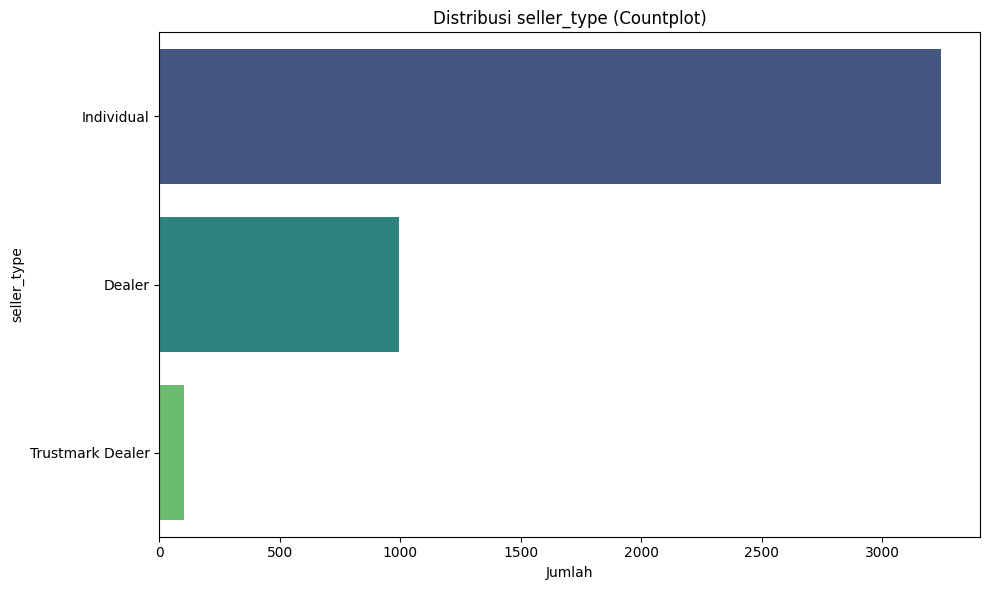

/tmp/ipykernel_1223/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


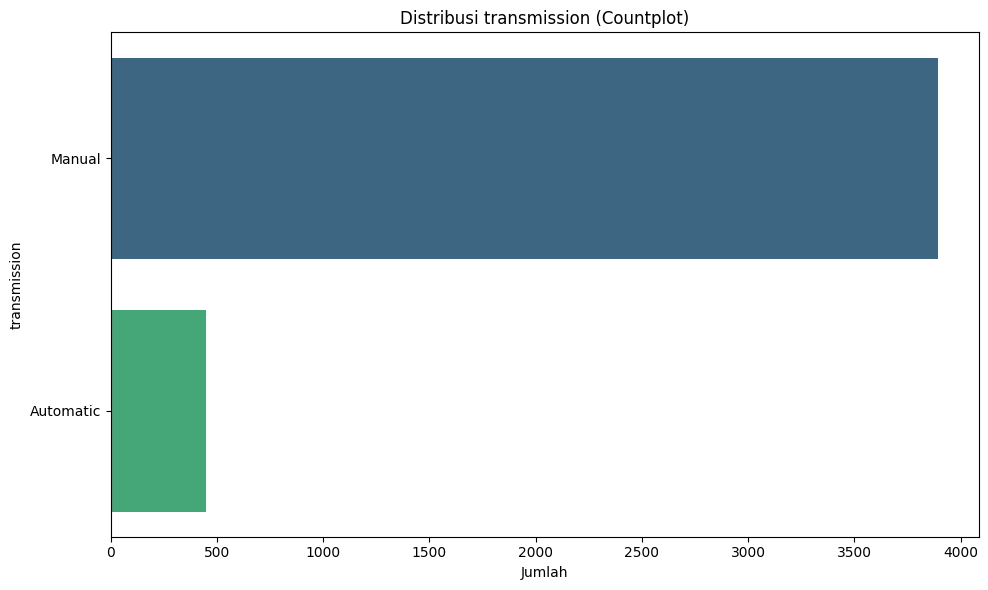

/tmp/ipykernel_1223/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


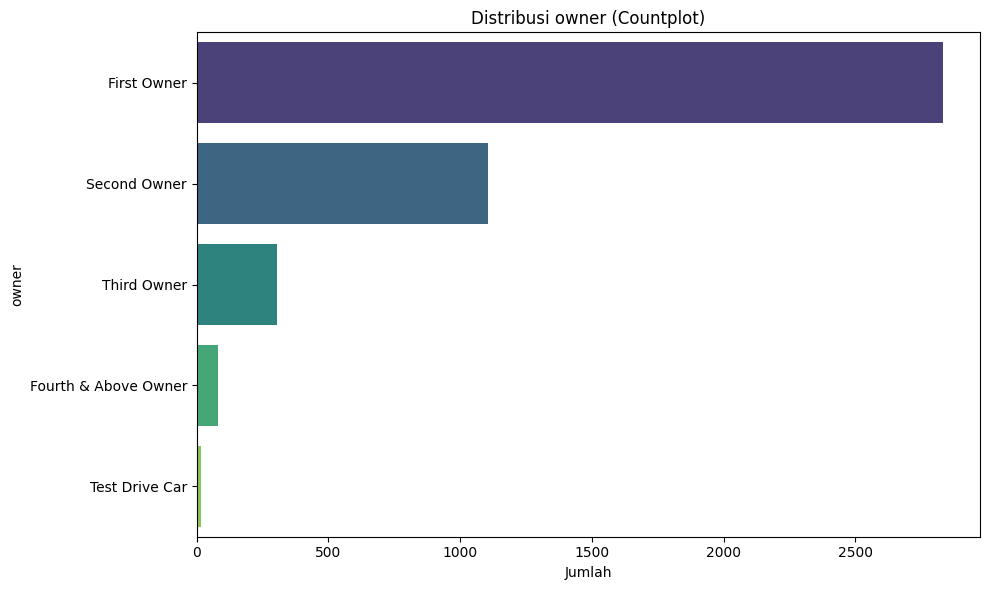

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")
for kolom in kolom_numerik:
    plt.figure(figsize=(15, 5))

    # Histplot dengan KDE
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom} (Histogram + KDE)')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

    # Boxplot untuk Outliers
    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
    sns.boxplot(y=df[kolom])
    plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
    plt.ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")
for kolom in kolom_kategorikal:
    plt.figure(figsize=(10, 6))
    # Countplot dengan pengurutan berdasarkan frekuensi
    sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {kolom} (Countplot)')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()


## **Analisis Bivariat & Multivariat (Bivariate & Multivariate Analysis)**

### 1. Heatmap Korelasi Antar Kolom Numerik ###


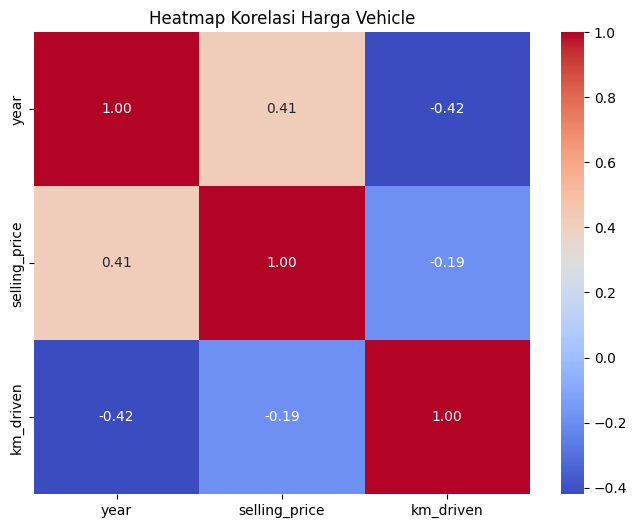


### 2. Scatter Plot Hubungan Kilometer (km_driven) vs Harga Jual (selling_price) ###


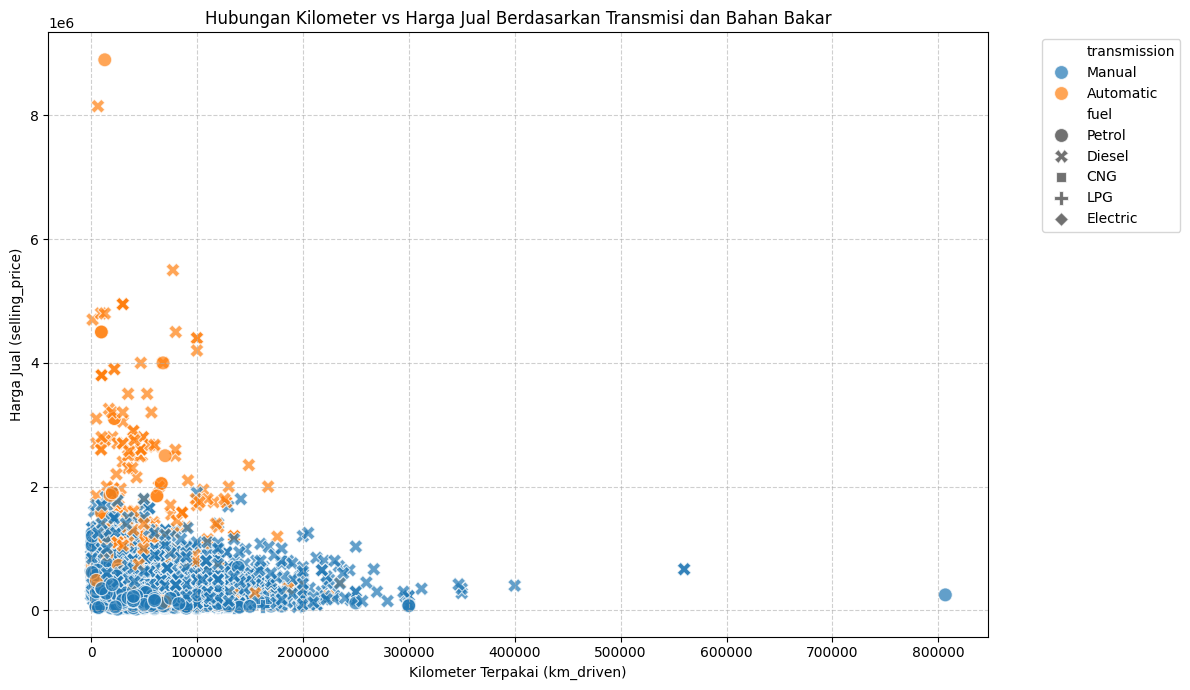

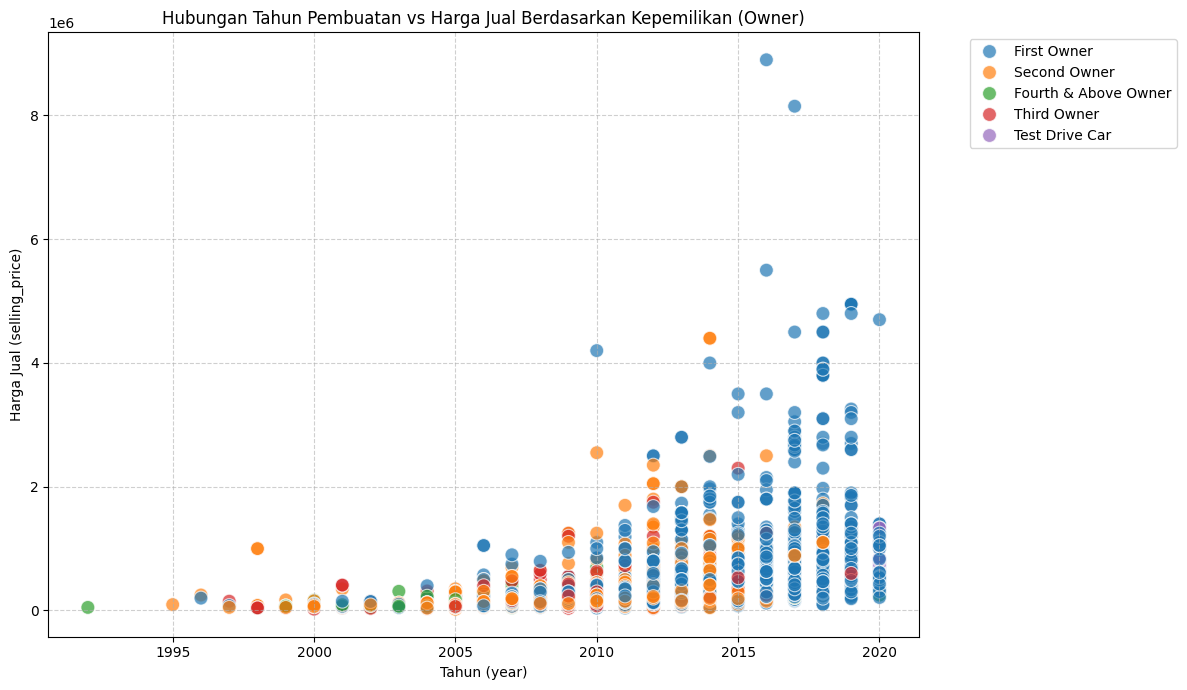


### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###


/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


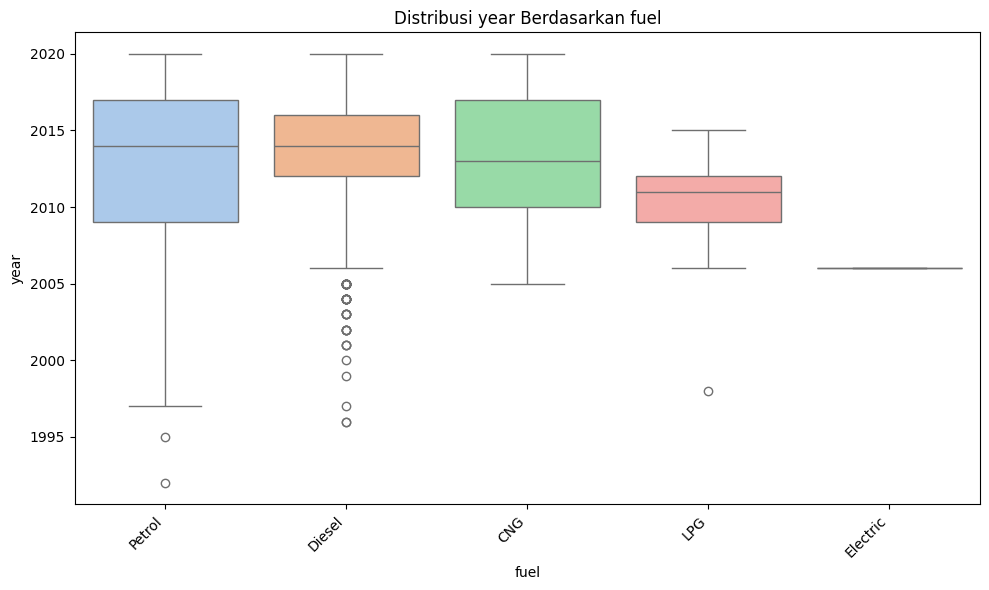

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


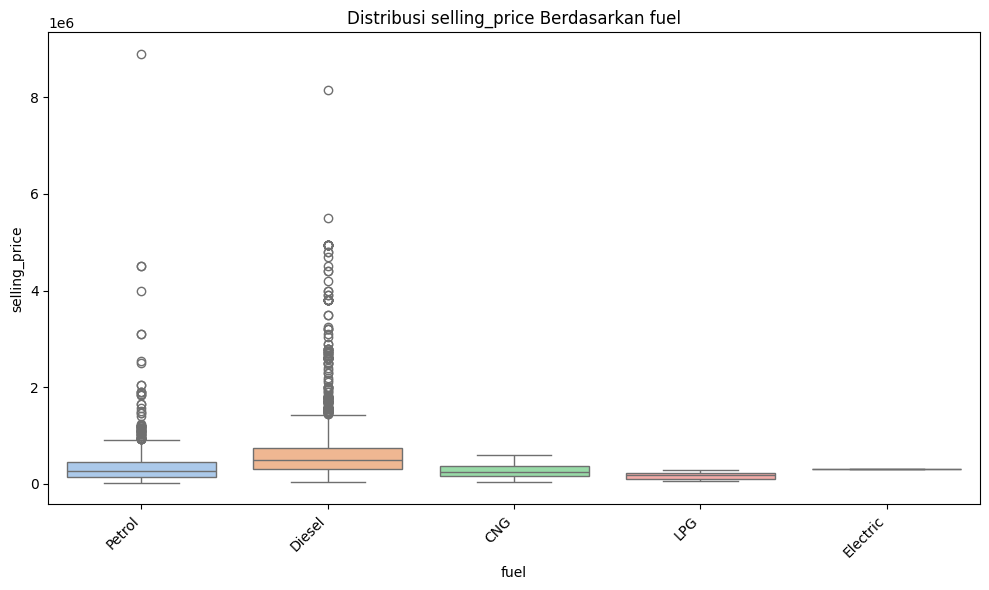

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


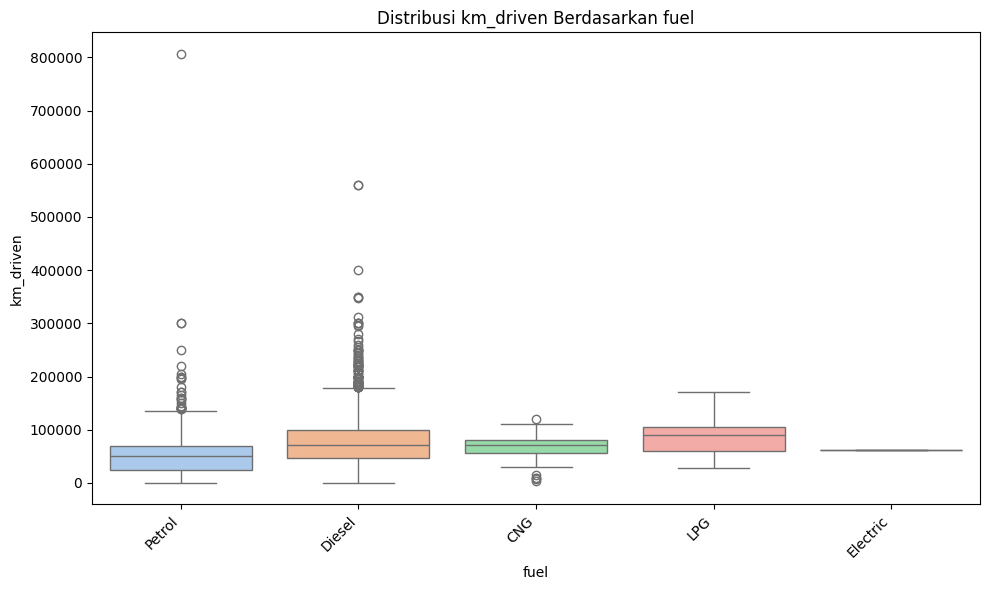

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


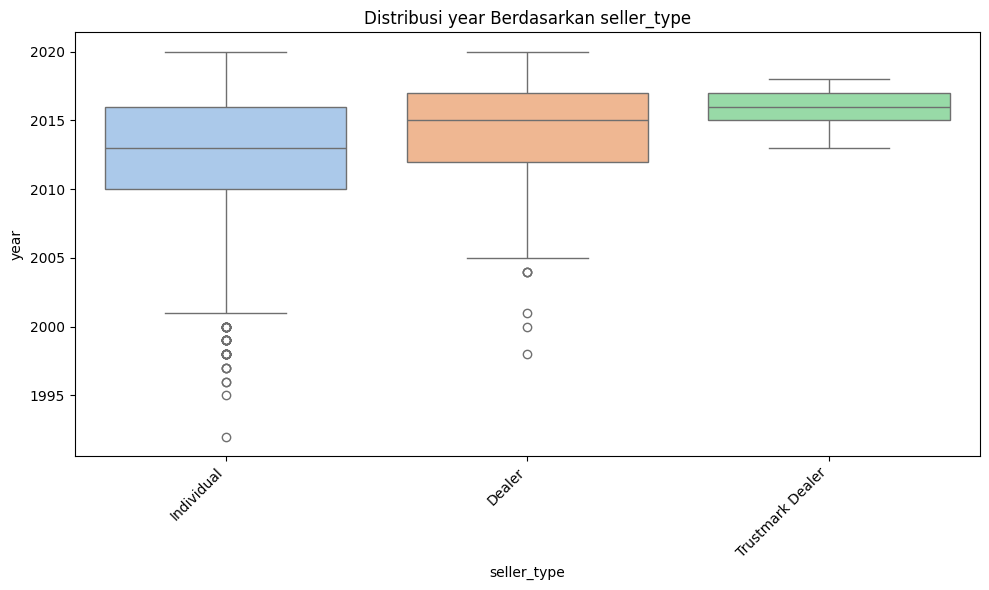

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


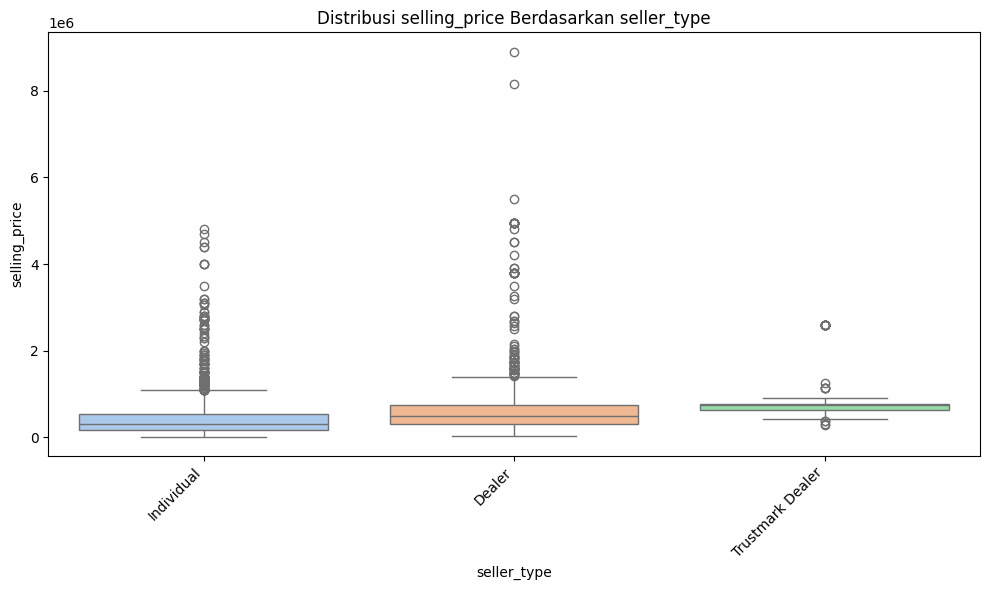

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


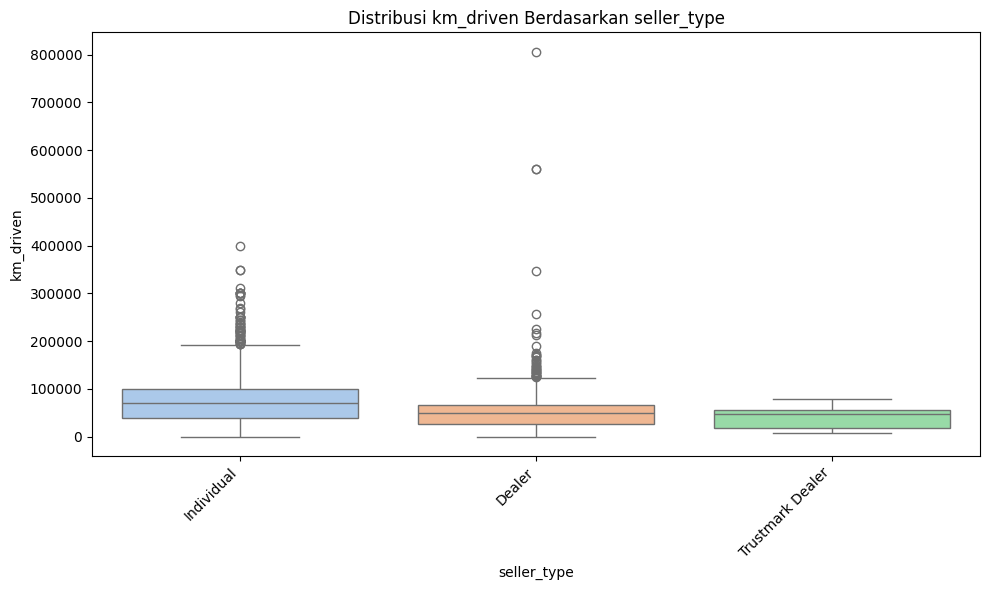

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


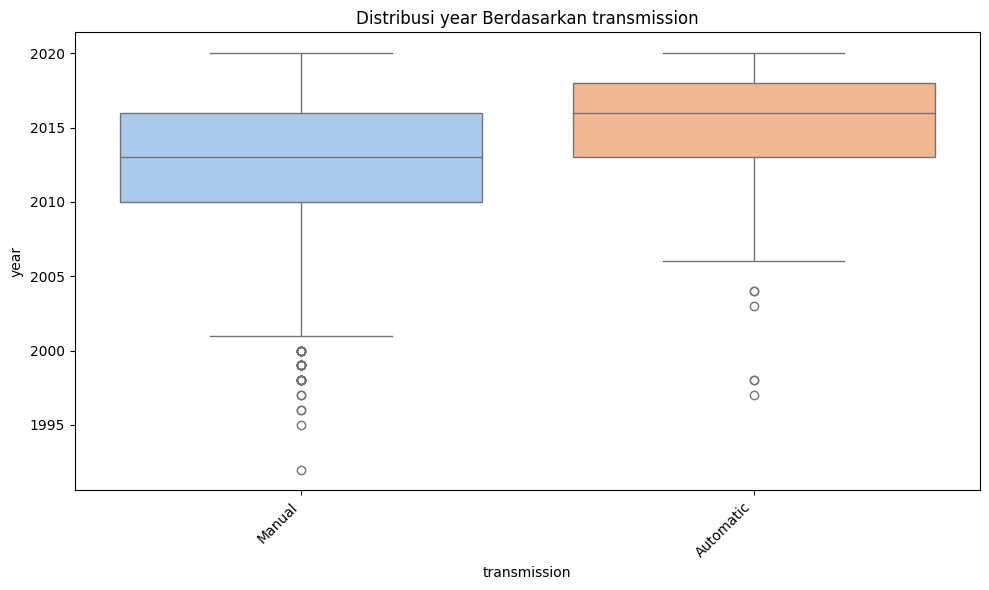

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


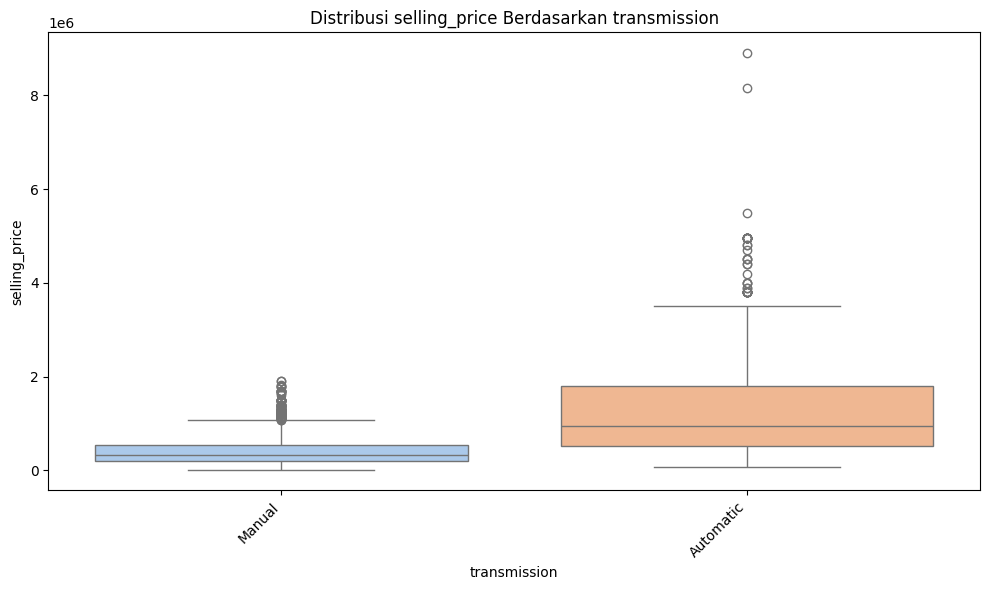

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


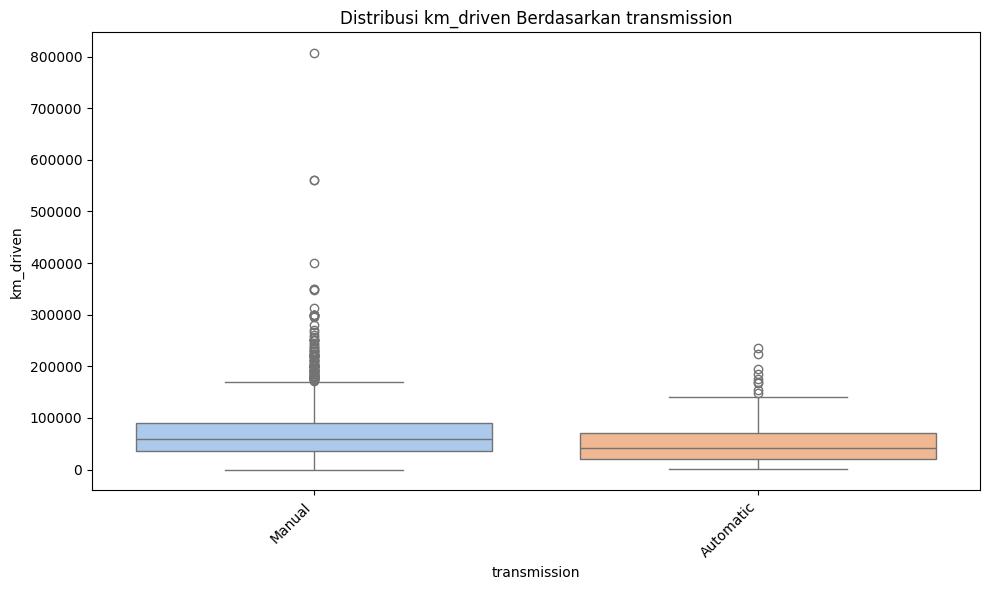

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


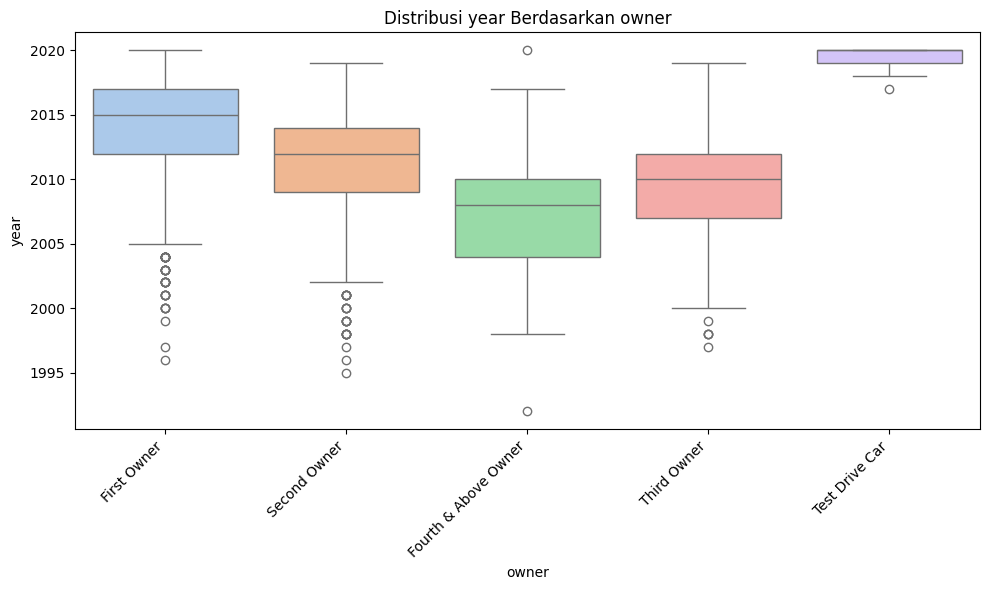

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


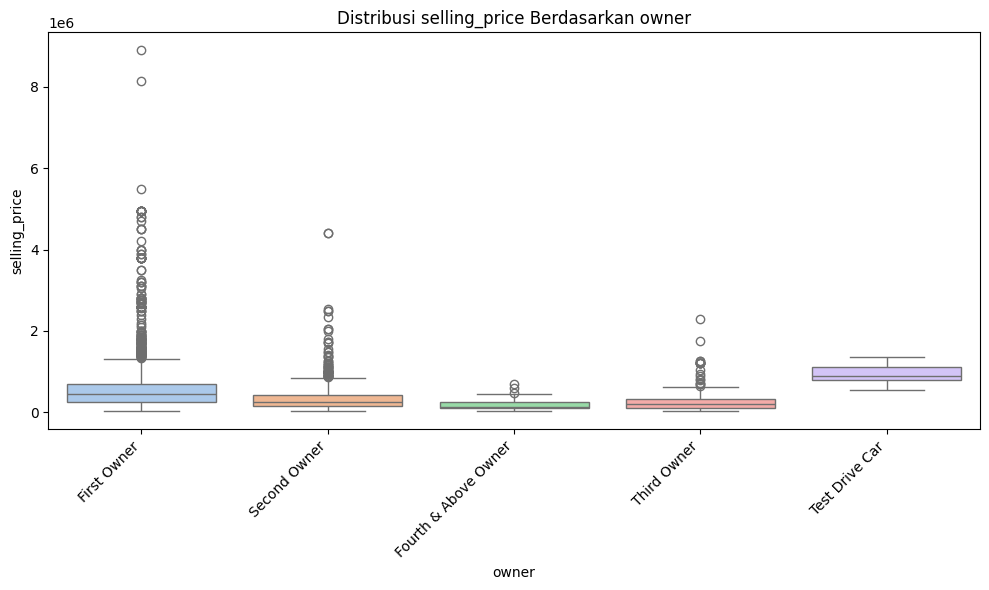

/tmp/ipykernel_1223/3877310894.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


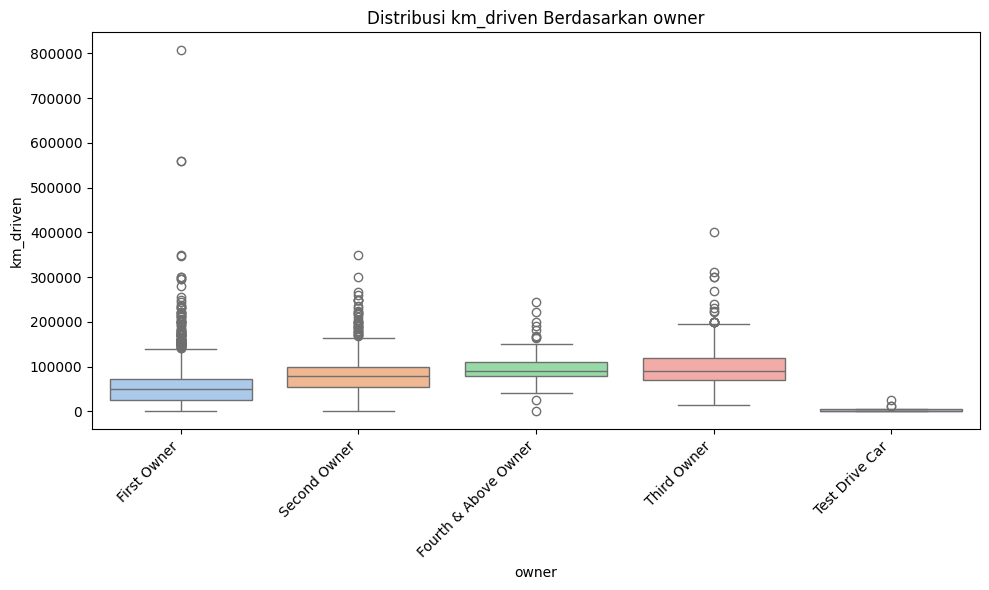

In [12]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

# Kita bisa abaikan kolom 'name' dari visualisasi boxplot berulang karena kategorinya terlalu banyak
kolom_kat_visualisasi = [col for col in kolom_kategorikal if col != 'name']

print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")
plt.figure(figsize=(8, 6))
correlation_matrix = df[kolom_numerik].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Harga Vehicle')
plt.show()

print("\n### 2. Scatter Plot Hubungan Kilometer (km_driven) vs Harga Jual (selling_price) ###")
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='km_driven',
    y='selling_price',
    hue='transmission',
    style='fuel',
    s=100,
    alpha=0.7
)
plt.title('Hubungan Kilometer vs Harga Jual Berdasarkan Transmisi dan Bahan Bakar')
plt.xlabel('Kilometer Terpakai (km_driven)')
plt.ylabel('Harga Jual (selling_price)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Hubungan Tahun Pembuatan vs Harga Jual
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='year',
    y='selling_price',
    hue='owner',
    s=100,
    alpha=0.7
)
plt.title('Hubungan Tahun Pembuatan vs Harga Jual Berdasarkan Kepemilikan (Owner)')
plt.xlabel('Tahun (year)')
plt.ylabel('Harga Jual (selling_price)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###")
# Menggunakan variabel kategori pilihan (fuel, seller_type, transmission, owner)
for kat_kolom in kolom_kat_visualisasi:
    for num_kolom in kolom_numerik:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')
        plt.title(f'Distribusi {num_kolom} Berdasarkan {kat_kolom}')
        plt.xlabel(kat_kolom)
        plt.ylabel(num_kolom)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# PREPROCESSING DATA

## Drop Data Duplikat

In [18]:
import pandas as pd
df_cleaned = df.drop_duplicates()
print(df_cleaned.duplicated().sum())

0


## Fitur engineering

In [24]:
# Menghindari SettingWithCopyWarning dengan membuat copy eksplisit
df_cleaned = df_cleaned.copy()

# Membuat Fitur Baru: 'car_age' (Umur Mobil)
# asumsi tahun saat ini
df_cleaned['car_age'] = 2026 - df_cleaned['year']


print("Fitur baru 'car_age'")
print(df_cleaned[['name', 'year', 'car_age']].head())

Fitur baru 'car_age'
                       name  year  car_age
0             Maruti 800 AC  2007       19
1  Maruti Wagon R LXI Minor  2007       19
2      Hyundai Verna 1.6 SX  2012       14
3    Datsun RediGO T Option  2017        9
4     Honda Amaze VX i-DTEC  2014       12


## Pemisahan Fitur X dan y

In [ ]:
X = df_cleaned.drop(columns=['selling_price'])
y = df_cleaned['selling_price']

## Encoding Data

In [19]:
import pandas as pd

# Karena kolom 'name' memiliki terlalu banyak kategori unik,
# kita bisa mengambil merek utamanya saja (kata pertama dari nama mobil)
# sebagai fitur baru, lalu menghapus kolom 'name' yang asli.
df_cleaned['brand'] = df_cleaned['name'].apply(lambda x: x.split(' ')[0])

# Melakukan One-Hot Encoding pada fitur kategorikal
# Kolom yang akan di-encode: 'brand', 'fuel', 'seller_type', 'transmission', 'owner'
kolom_kategori = ['brand', 'fuel', 'seller_type', 'transmission', 'owner']

# Menggunakan pd.get_dummies untuk mengubah data kategorikal menjadi numerikal
df_encoded = pd.get_dummies(df_cleaned.drop(columns=['name']), columns=kolom_kategori, drop_first=True)

# Menampilkan beberapa kolom pertama setelah di-encode
print("Dimensi data setelah Encoding:", df_encoded.shape)
print("\n--- 5 Baris Pertama Data Hasil Encoding ---")
display(df_encoded.head())

# Memperbarui X dan y berdasarkan dataset yang sudah di-encode
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

Dimensi data setelah Encoding: (3577, 42)

--- 5 Baris Pertama Data Hasil Encoding ---


/tmp/ipykernel_1223/510894775.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['brand'] = df_cleaned['name'].apply(lambda x: x.split(' ')[0])


,year,selling_price,km_driven,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,brand_Force,...,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,60000,70000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
1,2007,135000,50000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
2,2012,600000,100000,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,2017,250000,46000,False,False,False,False,True,False,False,...,False,False,True,True,False,True,False,False,False,False
4,2014,450000,141000,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False


## Split Data Train & Test

In [25]:
from sklearn.model_selection import train_test_split

# Melakukan split data dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran hasil pembagian
print("Pembagian Data Berhasil Selesai!")
print(f"Ukuran X_train : {X_train.shape}")
print(f"Ukuran X_test  : {X_test.shape}")
print(f"Ukuran y_train : {y_train.shape}")
print(f"Ukuran y_test  : {y_test.shape}")

Pembagian Data Berhasil Selesai!
Ukuran X_train : (2861, 41)
Ukuran X_test  : (716, 41)
Ukuran y_train : (2861,)
Ukuran y_test  : (716,)


## Scaling Data

In [26]:
from sklearn.preprocessing import StandardScaler

# Memisahkan fitur numerik kontinu yang perlu diskalakan
fitur_numerik = ['year', 'km_driven', 'car_age']

# Pastikan kolom-kolom tersebut ada di dataset sebelum scaling
fitur_numerik = [col for col in fitur_numerik if col in X_train.columns]

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Membuat salinan agar data asli aman
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Melakukan fit dan transform pada data Train, lalu transform pada data Test
X_train_scaled[fitur_numerik] = scaler.fit_transform(X_train[fitur_numerik])
X_test_scaled[fitur_numerik] = scaler.transform(X_test[fitur_numerik])

print("Skalasi Fitur Berhasil Selesai!")
print("\n--- Contoh Data Train Setelah Skalasi (3 Baris Pertama) ---")
display(X_train_scaled[fitur_numerik].head(3))

Skalasi Fitur Berhasil Selesai!

--- Contoh Data Train Setelah Skalasi (3 Baris Pertama) ---


,year,km_driven
2348,0.245936,1.348972
1250,0.955234,-1.029894
955,-1.409091,-0.202462


## Modeling

In [27]:
from sklearn.linear_model import LinearRegression

# Inisialisasi model Linear Regression
model_lr = LinearRegression()

# Melatih model menggunakan data training yang sudah diskalakan
model_lr.fit(X_train_scaled, y_train)

# Melakukan prediksi pada data train dan data test
y_pred_train = model_lr.predict(X_train_scaled)
y_pred_test = model_lr.predict(X_test_scaled)

print("Model Linear Regression berhasil dibuat dan dilatih!")
print(f"Intercept: {model_lr.intercept_}")
print(f"Jumlah koefisien (bobot fitur): {len(model_lr.coef_)}")

Model Linear Regression berhasil dibuat dan dilatih!
Intercept: 600495.2181340875
Jumlah koefisien (bobot fitur): 41


## Evaluasi

=== HASIL EVALUASI MODEL LINEAR REGRESSION ===
R² Score  | Train: 0.6608 | Test: 0.5384
MAE       | Train: 162856.05 | Test: 180194.99
RMSE      | Train: 287436.88 | Test: 385606.09


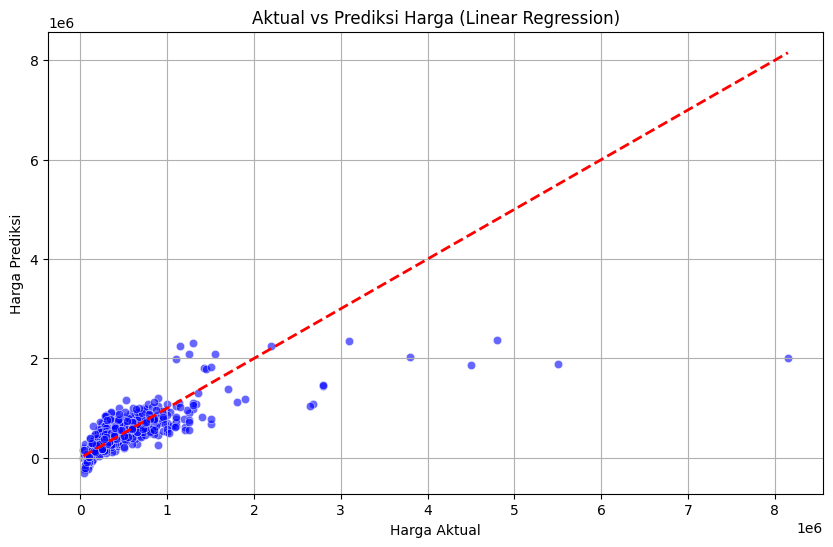

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menghitung Metrik Evaluasi untuk Data Train dan Test
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=== HASIL EVALUASI MODEL LINEAR REGRESSION ===")
print(f"R² Score  | Train: {r2_train:.4f} | Test: {r2_test:.4f}")
print(f"MAE       | Train: {mae_train:.2f} | Test: {mae_test:.2f}")
print(f"RMSE      | Train: {rmse_train:.2f} | Test: {rmse_test:.2f}")

# Visualisasi Aktual vs Prediksi
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Aktual vs Prediksi Harga (Linear Regression)')
plt.xlabel('Harga Aktual')
plt.ylabel('Harga Prediksi')
plt.grid(True)
plt.show()